In [37]:
import pandas as pd
from torch.utils.data import Dataset,DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split

In [38]:
torch.manual_seed(42)

In [39]:
df = pd.read_csv('https://raw.githubusercontent.com/mostafizcse007/Deep-Learning/refs/heads/main/Week%202/fmnist_small.csv')

In [40]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


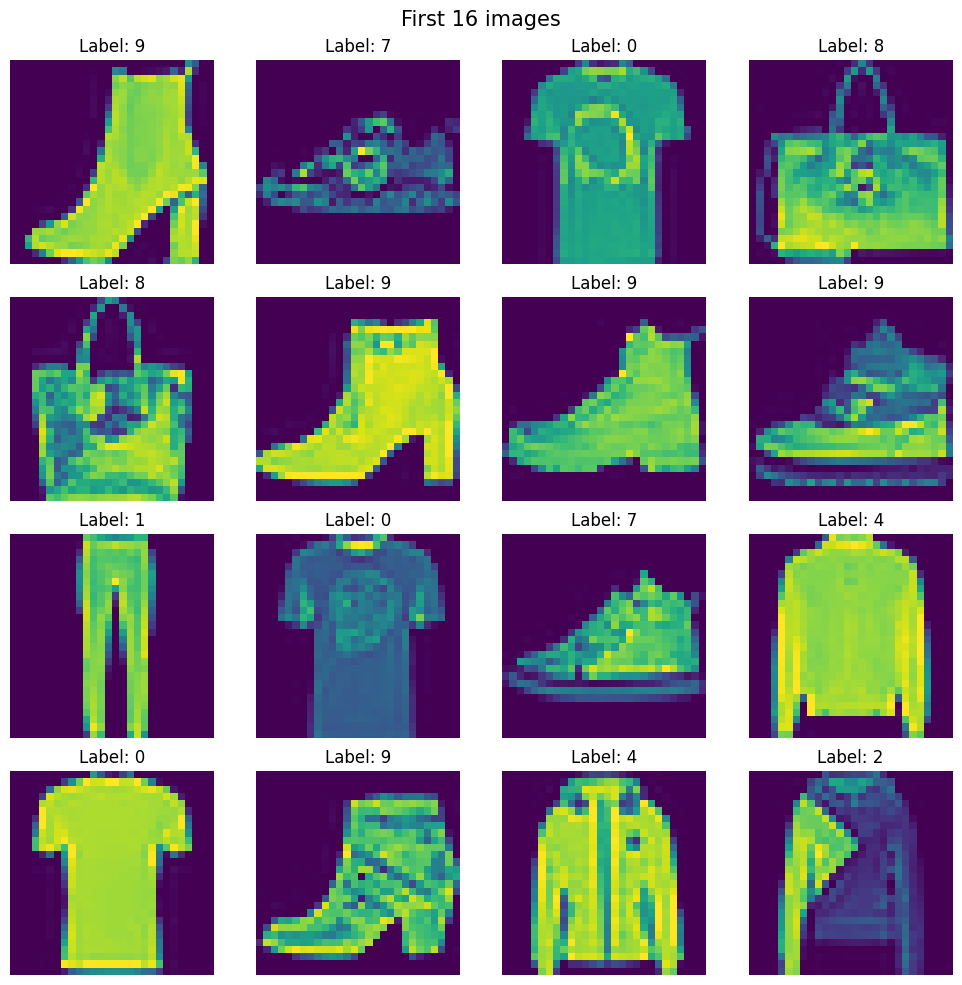

In [41]:
fig,axes = plt.subplots(4,4,figsize=(10,10))
plt.suptitle("First 16 images",fontsize=15)

for i,ax in enumerate(axes.flat):
    img = df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i,0]}")
    plt.tight_layout()
plt.show()

In [42]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [43]:
X = X/255.0

In [44]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)

In [45]:
X_train.shape

(4800, 784)

In [46]:
class CustomDataset(Dataset):
    def __init__(self,features,labels):
        self.features = torch.tensor(features.values,dtype = torch.float32)
        self.labels = torch.tensor(labels.values,dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self,index):
        return self.features[index],self.labels[index]


In [47]:
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test,y_test)

In [48]:
train_loader = DataLoader(train_dataset,shuffle=True,batch_size=32,pin_memory=True)
test_loader = DataLoader(test_dataset,shuffle=False,batch_size=32,pin_memory=True)

In [49]:
class MyNN(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )

    def forward(self,x):
        return self.model(x)

In [55]:
epochs = 1000
learning_rate = .01

In [56]:
model = MyNN(X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=learning_rate)

In [57]:
for epoch in range(epochs):
    epoch_loss = 0
    for batch_feature,batch_label in train_loader:
        outputs = model(batch_feature)
        loss = criterion(outputs,batch_label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}: {epoch_loss/len(train_loader)}")

Epoch 1: 0.9007713838418325
Epoch 2: 0.6378339093923568
Epoch 3: 0.5581335614124934
Epoch 4: 0.4908355874816577
Epoch 5: 0.4663794755935669
Epoch 6: 0.42755969683329265
Epoch 7: 0.4466976158320904
Epoch 8: 0.43213957741856573
Epoch 9: 0.3775720126430194
Epoch 10: 0.3654306527475516
Epoch 11: 0.374276139040788
Epoch 12: 0.33535761694113414
Epoch 13: 0.32133213823040324
Epoch 14: 0.3272436135013898
Epoch 15: 0.30137163517375787
Epoch 16: 0.3201040973762671
Epoch 17: 0.29235268572966255
Epoch 18: 0.2862340957671404
Epoch 19: 0.25497119734684626
Epoch 20: 0.2651655355840921
Epoch 21: 0.2812534990285834
Epoch 22: 0.2558263808240493
Epoch 23: 0.28231552431980766
Epoch 24: 0.3260186851521333
Epoch 25: 0.26690105771025024
Epoch 26: 0.23855123079692325
Epoch 27: 0.26037298204998177
Epoch 28: 0.24862028217564028
Epoch 29: 0.22451319803794226
Epoch 30: 0.22590614850322405
Epoch 31: 0.23389649890363218
Epoch 32: 0.2704377326493462
Epoch 33: 0.2304962227679789
Epoch 34: 0.19362059112638236
Epoch 35

In [58]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [59]:
total = 0;correct = 0
with torch.no_grad():
    for batch_feature,batch_label in test_loader:
        outputs = model(batch_feature)
        _,predicted = torch.max(outputs,1)
        total += batch_feature.shape[0]
        correct += (predicted == batch_label).sum().item()
    print(correct/total)

0.8225
